STATS 507 Final Project

Haoran Li (haoransl)

Disclosure: ChatGPT was used to help with and generate the coding components

Preprocessing

1. handle missing values

In [127]:
import pandas as pd
songs = pd.read_csv("spotify_songs.csv")

In [128]:
null_songs = songs[songs.isnull().any(axis=1)]
print(null_songs)

                     track_id track_name track_artist  track_popularity  \
8151   69gRFGOWY9OMpFJgFol1u0        NaN          NaN                 0   
9282   5cjecvX0CmC9gK0Laf5EMQ        NaN          NaN                 0   
9283   5TTzhRSWQS4Yu8xTgAuq6D        NaN          NaN                 0   
19568  3VKFip3OdAvv4OfNTgFWeQ        NaN          NaN                 0   
19811  69gRFGOWY9OMpFJgFol1u0        NaN          NaN                 0   

               track_album_id track_album_name track_album_release_date  \
8151   717UG2du6utFe7CdmpuUe3              NaN               2012-01-05   
9282   3luHJEPw434tvNbme3SP8M              NaN               2017-12-01   
9283   3luHJEPw434tvNbme3SP8M              NaN               2017-12-01   
19568  717UG2du6utFe7CdmpuUe3              NaN               2012-01-05   
19811  717UG2du6utFe7CdmpuUe3              NaN               2012-01-05   

            playlist_name             playlist_id playlist_genre  ... key  \
8151              HIP

In [129]:
songs = songs.dropna()

2. Drop duplicate rows

In [130]:
songs = songs.drop_duplicates(subset="track_id", keep="first")
songs = songs.drop_duplicates(subset=["track_name", "track_artist"], keep="first")

In [131]:
songs.shape

(26229, 23)

In [132]:
print(songs.columns)

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')


3. remove useless columns

In [133]:
songs = songs.drop(["track_id", "track_album_id", "track_album_name", "playlist_name", "playlist_id", "playlist_subgenre"], axis=1)
print(songs.columns)

Index(['track_name', 'track_artist', 'track_popularity',
       'track_album_release_date', 'playlist_genre', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='object')


4. remove multicollinearity

In [134]:
import numpy as np
numeric_data = songs.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()
print(correlation_matrix)

                  track_popularity  danceability    energy       key  \
track_popularity          1.000000      0.049554 -0.106143 -0.005094   
danceability              0.049554      1.000000 -0.073411  0.006852   
energy                   -0.106143     -0.073411  1.000000  0.012853   
key                      -0.005094      0.006852  0.012853  1.000000   
loudness                  0.038343      0.016813  0.685670 -0.000184   
mode                      0.020833     -0.052883 -0.008069 -0.174215   
speechiness               0.006600      0.182608 -0.025860  0.019636   
acousticness              0.093039     -0.035277 -0.551350  0.005060   
instrumentalness         -0.130870     -0.000778  0.020238  0.006809   
liveness                 -0.052570     -0.129599  0.166329  0.004605   
valence                   0.029952      0.334737  0.150038  0.022246   
tempo                     0.004354     -0.174608  0.152070 -0.007305   
duration_ms              -0.137522     -0.083870  0.019834  0.01

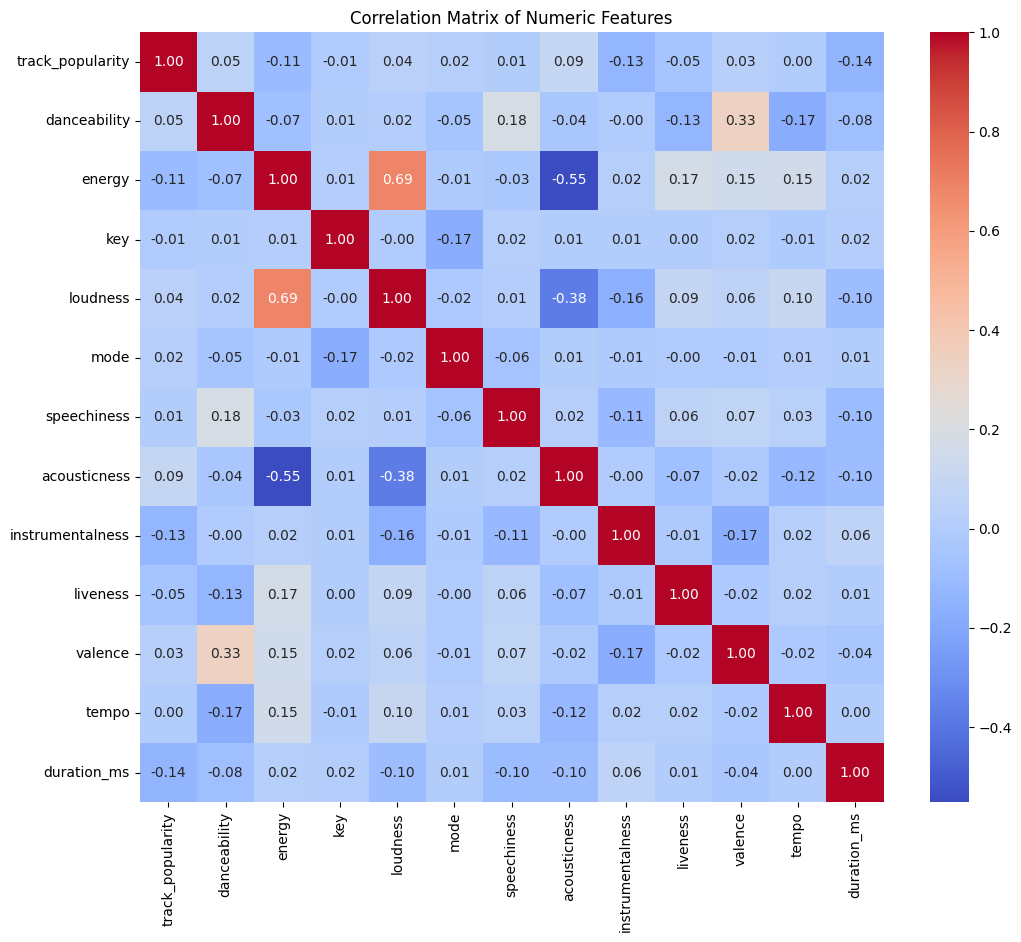

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(
    numeric_data.corr(), 
    annot=True,     
    fmt=".2f",    
    cmap="coolwarm"
)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [73]:
songs = songs.drop(["loudness"], axis=1)
songs.columns

Index(['track_name', 'track_artist', 'track_popularity',
       'track_album_release_date', 'playlist_genre', 'danceability', 'energy',
       'key', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='object')

5. encode categorical features

In [74]:
songs['key'] = songs['key'].astype('category')
songs['mode'] = songs['mode'].astype('category')
songs['track_name'] = songs['track_name'].astype('category')
songs['track_artist'] = songs['track_artist'].astype('category')
songs['playlist_genre'] = songs['playlist_genre'].astype('category')
print(songs.dtypes)

track_name                  category
track_artist                category
track_popularity               int64
track_album_release_date      object
playlist_genre              category
danceability                 float64
energy                       float64
key                         category
mode                        category
speechiness                  float64
acousticness                 float64
instrumentalness             float64
liveness                     float64
valence                      float64
tempo                        float64
duration_ms                    int64
dtype: object


6. create song age feature

In [75]:
songs['release_year'] = songs['track_album_release_date'].astype(str).str[:4]
songs['release_year'] = pd.to_numeric(songs['release_year'], errors='coerce')
songs['age_of_song_in_years'] = 2025 - songs['release_year']
print(songs['age_of_song_in_years'].isna().sum())
songs.head(3)

0


,track_name,track_artist,track_popularity,track_album_release_date,playlist_genre,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year,age_of_song_in_years
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2019-06-14,pop,0.748,0.916,6,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,2019,6
1,Memories - Dillon Francis Remix,Maroon 5,67,2019-12-13,pop,0.726,0.815,11,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,2019,6
2,All the Time - Don Diablo Remix,Zara Larsson,70,2019-07-05,pop,0.675,0.931,1,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2019,6


In [76]:
songs = songs.drop("track_album_release_date", axis=1)
songs.columns

Index(['track_name', 'track_artist', 'track_popularity', 'playlist_genre',
       'danceability', 'energy', 'key', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
       'release_year', 'age_of_song_in_years'],
      dtype='object')

In [77]:
songs = songs.drop("release_year", axis=1)
songs.columns

Index(['track_name', 'track_artist', 'track_popularity', 'playlist_genre',
       'danceability', 'energy', 'key', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
       'age_of_song_in_years'],
      dtype='object')

CatBoost

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = songs.drop(["track_popularity", "track_name"], axis=1)
y = songs["track_popularity"]

categorical_features = ["track_artist", "key", "mode", "playlist_genre"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=categorical_features)

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=100
)

cat_model.fit(train_pool)
pred_cat = cat_model.predict(test_pool)
print("CatBoost (with track_artist as categorical):")
print("MAE:", mean_absolute_error(y_test, pred_cat))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_cat)))
print("R²:", r2_score(y_test, pred_cat))

feat_imp = cat_model.get_feature_importance(prettified=True)
print("\nFeature Importances (descending):")
print(feat_imp)

0:	learn: 23.0300663	total: 11.3ms	remaining: 5.66s
100:	learn: 19.4680000	total: 710ms	remaining: 2.8s
200:	learn: 18.8652022	total: 1.53s	remaining: 2.28s
300:	learn: 18.3933164	total: 2.37s	remaining: 1.57s
400:	learn: 18.0358983	total: 3.27s	remaining: 807ms
499:	learn: 17.6952906	total: 4.12s	remaining: 0us
CatBoost (with track_artist as categorical):
MAE: 15.156611131609441
RMSE: 19.1212323619527
R²: 0.31163505813649817

Feature Importances (descending):
              Feature Id  Importances
0           track_artist    24.598425
1   age_of_song_in_years    20.170439
2         playlist_genre    10.024196
3       instrumentalness     5.495625
4                  tempo     5.117190
5            speechiness     4.753568
6                 energy     4.688636
7           acousticness     4.453891
8            duration_ms     4.326972
9                valence     4.249507
10          danceability     4.195069
11              liveness     4.090291
12                   key     3.391986
13 

cross validation

In [59]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = songs.drop(["track_popularity", "track_name"], axis=1)
y = songs["track_popularity"]

categorical_features = ["track_artist", "key", "mode", "playlist_genre"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_model = CatBoostRegressor(
    random_state=42,
    verbose=0
)

param_grid = {
    "iterations": [200, 600],
    "learning_rate": [0.05, 0.1, 0.5],
    "depth": [6, 8, 10],
    "l2_leaf_reg": [1, 3, 5]
}

grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train, cat_features=categorical_features)

print("Best hyperparameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
pred_cat = best_model.predict(X_test)

print("\nCatBoost (cross-validated hyperparameters):")
print("MAE:", mean_absolute_error(y_test, pred_cat))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_cat)))
print("R²:", r2_score(y_test, pred_cat))

# Feature importance
feat_imp = best_model.get_feature_importance(prettified=True)
print("\nFeature Importances (descending):")
print(feat_imp)


Best hyperparameters: {'depth': 8, 'iterations': 600, 'l2_leaf_reg': 5, 'learning_rate': 0.05}

CatBoost (cross-validated hyperparameters):
MAE: 15.056259899420596
RMSE: 19.00506728316649
R²: 0.3199735447081895

Feature Importances (descending):
              Feature Id  Importances
0           track_artist    21.815990
1   age_of_song_in_years    18.927428
2         playlist_genre    10.778282
3       instrumentalness     5.977982
4                  tempo     5.710105
5           acousticness     5.028721
6            duration_ms     5.011909
7                 energy     4.917532
8           danceability     4.692478
9            speechiness     4.620776
10              liveness     4.168370
11               valence     4.166888
12                   key     3.521515
13                  mode     0.662024


In [82]:
train_pred = best_model.predict(X_train)
print("Train R²:", r2_score(y_train, train_pred))

Train R²: 0.5790016328691727


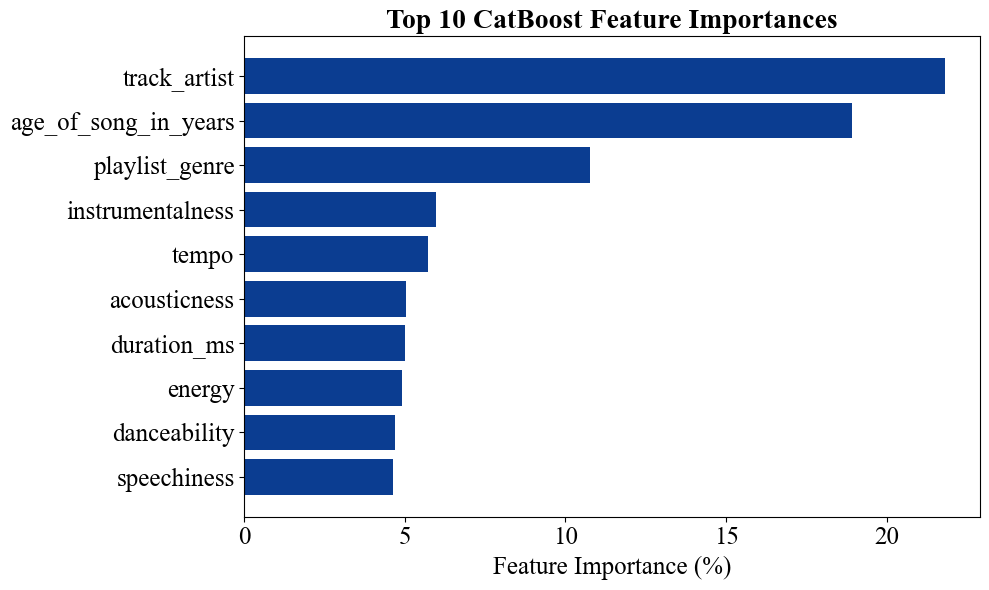

In [125]:
import matplotlib.pyplot as plt
import pandas as pd

importances = best_model.get_feature_importance()
feature_names = best_model.feature_names_
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='#0b3d91')
plt.xlabel('Feature Importance (%)', fontsize=18, fontname='Times New Roman')
plt.title('Top 10 CatBoost Feature Importances', fontsize=20, fontweight='bold', fontname='Times New Roman')
plt.xticks(fontsize=18, fontname='Times New Roman')
plt.yticks(fontsize=18, fontname='Times New Roman')

plt.tight_layout()
plt.show()


In [83]:
num_unique = songs["playlist_genre"].nunique()
print("Number of unique playlist_genre values:", num_unique)

Number of unique playlist_genre values: 6


7. 1-0 encode "key" and "playlist_genre"

In [84]:
songs = pd.get_dummies(songs, columns=["key", "playlist_genre"], drop_first=True)
songs.columns

Index(['track_name', 'track_artist', 'track_popularity', 'danceability',
       'energy', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'age_of_song_in_years',
       'key_1', 'key_2', 'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8',
       'key_9', 'key_10', 'key_11', 'playlist_genre_latin',
       'playlist_genre_pop', 'playlist_genre_r&b', 'playlist_genre_rap',
       'playlist_genre_rock'],
      dtype='object')

Modeling
1. target encode artist name
2. Normalization for models that need it

with normalization and without tfidf
1. linear 2. lasso 3. svr 4. mlp

In [85]:
from sklearn.model_selection import train_test_split
X = songs.drop(["track_popularity", "track_name"], axis=1)
y = songs["track_popularity"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

artist_mean = y_train.groupby(X_train["track_artist"]).mean()
X_train["track_artist_encoded"] = X_train["track_artist"].map(artist_mean)
X_test["track_artist_encoded"] = X_test["track_artist"].map(artist_mean)
global_mean = y_train.mean()
X_test["track_artist_encoded"] = X_test["track_artist_encoded"].fillna(global_mean)
X_train = X_train.drop("track_artist", axis=1)
X_test = X_test.drop("track_artist", axis=1)

/var/folders/qn/wlhml189465_cfh255g_zryh0000gn/T/ipykernel_41610/3377573165.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  artist_mean = y_train.groupby(X_train["track_artist"]).mean()


In [86]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_final = scaler.fit_transform(X_train)
X_test_final = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train_final, y_train)
train_pred = lr_model.predict(X_train_final)
train_r2 = r2_score(y_train, train_pred)
y_pred = lr_model.predict(X_test_final)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"Train R²: {train_r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

Linear Regression Performance:
Train R²: 0.621
MAE: 15.778
RMSE: 20.897
R²: 0.178


In [96]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lasso_model = Lasso(alpha=0.001, random_state=42)
lasso_model.fit(X_train_final, y_train)
train_pred = lasso_model.predict(X_train_final)
train_r2 = r2_score(y_train, train_pred)
y_pred = lasso_model.predict(X_test_final)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Lasso Regression Performance:")
print(f"Train R²: {train_r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

Lasso Regression Performance:
Train R²: 0.621
MAE: 15.779
RMSE: 20.898
R²: 0.178


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

knn_model = KNeighborsRegressor(n_neighbors=25)
knn_model.fit(X_train_final, y_train)
train_pred = knn_model.predict(X_train_final)
train_r2 = r2_score(y_train, train_pred)
y_pred = knn_model.predict(X_test_final)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("K-Nearest Neighbors Regression Performance:")
print(f"Train R²: {train_r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


K-Nearest Neighbors Regression Performance:
Train R²: 0.452
MAE: 16.568
RMSE: 20.729
R²: 0.191


In [97]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

svr_model = SVR(kernel='rbf', C=0.1, gamma='scale')
svr_model.fit(X_train_final, y_train)
train_pred = svr_model.predict(X_train_final)
train_r2 = r2_score(y_train, train_pred)
y_pred = svr_model.predict(X_test_final)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Support Vector Regression Performance:")
print(f"Train R²: {train_r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

Support Vector Regression Performance:
Train R²: 0.425
MAE: 16.516
RMSE: 20.592
R²: 0.202


In [98]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_final, y_train)
train_pred = mlp.predict(X_train_final)
train_r2 = r2_score(y_train, train_pred)
y_pred = mlp.predict(X_test_final)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MLP Regressor:")
print(f"Train R²: {train_r2:.3f}")
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MLP Regressor:
Train R²: 0.650
MAE: 15.578074059004516
RMSE: 20.523205289366334
R^2: 0.20699237308479768


with normalization and tfidf

In [99]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack

X = songs.drop(["track_popularity"], axis=1)
y = songs["track_popularity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

artist_mean = y_train.groupby(X_train["track_artist"]).mean()

X_train["track_artist_encoded"] = X_train["track_artist"].map(artist_mean)
X_test["track_artist_encoded"] = X_test["track_artist"].map(artist_mean)
global_mean = y_train.mean()
X_test["track_artist_encoded"] = X_test["track_artist_encoded"].fillna(global_mean)

X_train = X_train.drop("track_artist", axis=1)
X_test = X_test.drop("track_artist", axis=1)

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

tfidf_train = tfidf.fit_transform(X_train["track_name"])
tfidf_test = tfidf.transform(X_test["track_name"])
num_train = X_train.drop("track_name", axis=1)
num_test = X_test.drop("track_name", axis=1)
scaler = MinMaxScaler()
num_train_scaled = scaler.fit_transform(num_train)
num_test_scaled = scaler.transform(num_test)
X_train_final = hstack([tfidf_train, num_train_scaled])
X_test_final = hstack([tfidf_test, num_test_scaled])

/var/folders/qn/wlhml189465_cfh255g_zryh0000gn/T/ipykernel_41610/1950079757.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  artist_mean = y_train.groupby(X_train["track_artist"]).mean()


linear

In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_final, y_train)
pred = lr.predict(X_test_final)
train_pred = lr.predict(X_train_final)
train_r2 = r2_score(y_train, train_pred) 
print("Training R^2:", train_r2)
print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R^2:", r2_score(y_test, pred))

Training R^2: 0.7157758343155628
Linear Regression:
MAE: 16.74978565576972
RMSE: 22.274704624971356
R^2: 0.06586231418734312


In [101]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_final, y_train)
pred = lasso.predict(X_test_final)

train_pred = lasso.predict(X_train_final)
train_r2 = r2_score(y_train, train_pred) 
print("Training R^2:", train_r2)

print("\nLasso Regression:")
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R^2:", r2_score(y_test, pred))

Training R^2: 0.62500940563458

Lasso Regression:
MAE: 15.723271932532429
RMSE: 20.827990688936232
R^2: 0.18326393131822105


In [102]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=25)
knn.fit(X_train_final, y_train)
pred = knn.predict(X_test_final)
train_pred = knn.predict(X_train_final)
train_r2 = r2_score(y_train, train_pred) 

print("\nKNN:")
print("Training R^2:", train_r2)
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R^2:", r2_score(y_test, pred))


KNN:
Training R^2: 0.27632315179279465
MAE: 17.754380480365995
RMSE: 21.686935449610615
R^2: 0.11451061527583284


In [104]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=0.1)
svr.fit(X_train_final, y_train)
pred = svr.predict(X_test_final)
train_pred = svr.predict(X_train_final)
train_r2 = r2_score(y_train, train_pred) 

print("\nSVR (rbf):")
print("Training R^2:", train_r2)
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R^2:", r2_score(y_test, pred))


SVR (rbf):
Training R^2: 0.35150601090053757
MAE: 16.88891581859849
RMSE: 20.915497905420708
R^2: 0.1763866055547032


In [105]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=40,
    early_stopping=True,
    random_state=42
)

mlp.fit(X_train_final, y_train)
pred = mlp.predict(X_test_final)
train_pred = mlp.predict(X_train_final)
train_r2 = r2_score(y_train, train_pred) 

print("\nMLP:")
print("Training R^2:", train_r2)
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R^2:", r2_score(y_test, pred))



MLP:
Training R^2: 0.6892545890426413
MAE: 16.163256545966682
RMSE: 21.05704245074692
R^2: 0.16520136371220795


without normalization

In [106]:
X = songs.drop(["track_popularity", "track_name"], axis=1) 
y = songs["track_popularity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

artist_mean = y_train.groupby(X_train["track_artist"]).mean()
X_train["track_artist_encoded"] = X_train["track_artist"].map(artist_mean)
X_test["track_artist_encoded"] = X_test["track_artist"].map(artist_mean)
global_mean = y_train.mean()
X_test["track_artist_encoded"] = X_test["track_artist_encoded"].fillna(global_mean)

X_train = X_train.drop("track_artist", axis=1)
X_test = X_test.drop("track_artist", axis=1)

/var/folders/qn/wlhml189465_cfh255g_zryh0000gn/T/ipykernel_41610/3835826047.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  artist_mean = y_train.groupby(X_train["track_artist"]).mean()


In [107]:
def print_feature_importances(model, feature_names):
    importances = model.feature_importances_
    feat_imp = dict(zip(feature_names, importances))
    feat_imp_sorted = dict(sorted(feat_imp.items(), key=lambda x: x[1], reverse=True))
    for k, v in feat_imp_sorted.items():
        print(f"{k}: {v:.6f}")
    return feat_imp_sorted

In [109]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt = DecisionTreeRegressor(max_depth=7,random_state=42)
dt.fit(X_train, y_train)
pred = dt.predict(X_test)
train_pred = dt.predict(X_train)
train_r2 = r2_score(y_train, train_pred) 

print("Decision Tree:")
print("Training R^2:", train_r2)
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))
print("Feature Importances (descending):")
print_feature_importances(dt, X_train.columns)

Decision Tree:
Training R^2: 0.6419079606812816
MAE: 15.75277457706749
RMSE: 20.921173313942003
R²: 0.17593957085456657
Feature Importances (descending):
track_artist_encoded: 0.958056
age_of_song_in_years: 0.020318
playlist_genre_pop: 0.004901
tempo: 0.002799
acousticness: 0.002414
valence: 0.002370
liveness: 0.002310
duration_ms: 0.001533
instrumentalness: 0.001501
energy: 0.001416
speechiness: 0.001177
danceability: 0.000483
key_6: 0.000351
playlist_genre_latin: 0.000210
key_9: 0.000120
key_7: 0.000041
mode: 0.000000
key_1: 0.000000
key_2: 0.000000
key_3: 0.000000
key_4: 0.000000
key_5: 0.000000
key_8: 0.000000
key_10: 0.000000
key_11: 0.000000
playlist_genre_r&b: 0.000000
playlist_genre_rap: 0.000000
playlist_genre_rock: 0.000000


{'track_artist_encoded': np.float64(0.9580561832908204),
 'age_of_song_in_years': np.float64(0.020317807748965577),
 'playlist_genre_pop': np.float64(0.004900612551645443),
 'tempo': np.float64(0.002799158210197541),
 'acousticness': np.float64(0.002413537919008898),
 'valence': np.float64(0.0023696433769220134),
 'liveness': np.float64(0.0023103395777065044),
 'duration_ms': np.float64(0.001533319286046843),
 'instrumentalness': np.float64(0.0015013552541380175),
 'energy': np.float64(0.001416483236676299),
 'speechiness': np.float64(0.001176722930556846),
 'danceability': np.float64(0.00048285525769659364),
 'key_6': np.float64(0.000351000572833458),
 'playlist_genre_latin': np.float64(0.000209814566837393),
 'key_9': np.float64(0.00012032958820568649),
 'key_7': np.float64(4.083663174239677e-05),
 'mode': np.float64(0.0),
 'key_1': np.float64(0.0),
 'key_2': np.float64(0.0),
 'key_3': np.float64(0.0),
 'key_4': np.float64(0.0),
 'key_5': np.float64(0.0),
 'key_8': np.float64(0.0),
 

In [110]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=500,   
    max_depth=15,   
    random_state=42,
    n_jobs=-1     
)

rf.fit(X_train, y_train)
pred = rf.predict(X_test)
train_pred = rf.predict(X_train)
train_r2 = r2_score(y_train, train_pred) 

print("\nRandom Forest:")
print("Training R^2:", train_r2)
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))
print("Feature Importances (descending):")
print_feature_importances(rf, X_train.columns)


Random Forest:
Training R^2: 0.8659961530129905
MAE: 15.453899519491804
RMSE: 20.530270060062126
R²: 0.2064463198504789
Feature Importances (descending):
track_artist_encoded: 0.720416
age_of_song_in_years: 0.029784
liveness: 0.026845
tempo: 0.026644
danceability: 0.025174
acousticness: 0.024809
duration_ms: 0.024442
speechiness: 0.024400
valence: 0.024212
energy: 0.023730
instrumentalness: 0.015780
playlist_genre_pop: 0.006121
mode: 0.002409
key_1: 0.002211
playlist_genre_rap: 0.002153
key_8: 0.001952
key_2: 0.001852
key_7: 0.001833
key_11: 0.001766
key_6: 0.001749
key_5: 0.001649
playlist_genre_latin: 0.001643
key_4: 0.001602
key_9: 0.001574
playlist_genre_r&b: 0.001390
key_10: 0.001383
playlist_genre_rock: 0.001265
key_3: 0.001211


{'track_artist_encoded': np.float64(0.7204164884770474),
 'age_of_song_in_years': np.float64(0.02978393341465453),
 'liveness': np.float64(0.02684481752306486),
 'tempo': np.float64(0.026644425300496637),
 'danceability': np.float64(0.02517373734846026),
 'acousticness': np.float64(0.024809063697576763),
 'duration_ms': np.float64(0.024442304141474094),
 'speechiness': np.float64(0.02440006663048719),
 'valence': np.float64(0.024211613487213218),
 'energy': np.float64(0.023729532704418698),
 'instrumentalness': np.float64(0.01578012203801899),
 'playlist_genre_pop': np.float64(0.006121160703368468),
 'mode': np.float64(0.0024094231002167415),
 'key_1': np.float64(0.0022110533563750243),
 'playlist_genre_rap': np.float64(0.002152542819497734),
 'key_8': np.float64(0.0019523494281076539),
 'key_2': np.float64(0.0018520396765723587),
 'key_7': np.float64(0.0018326004336490919),
 'key_11': np.float64(0.0017662055649168404),
 'key_6': np.float64(0.0017487672780431955),
 'key_5': np.float64(

In [111]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgbm = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.003,
    max_depth=10, 
    random_state=42
)

lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_test)
train_pred = lgbm.predict(X_train)
train_r2 = r2_score(y_train, train_pred) 

print("\nLightGBM:")
print("Training R^2:", train_r2)
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))
print("Feature Importances (descending):")
print_feature_importances(lgbm, X_train.columns)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000998 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2646
[LightGBM] [Info] Number of data points in the train set: 20983, number of used features: 28
[LightGBM] [Info] Start training from score 39.414478

LightGBM:
Training R^2: 0.6796981042115209
MAE: 15.4204140749611
RMSE: 20.389628539839443
R²: 0.21728147380726426
Feature Importances (descending):
track_artist_encoded: 11506.000000
age_of_song_in_years: 9495.000000
duration_ms: 4187.000000
liveness: 4101.000000
tempo: 4077.000000
energy: 4003.000000
speechiness: 3835.000000
acousticness: 3645.000000
danceability: 3478.000000
valence: 3298.000000
instrumentalness: 3088.000000
playlist_genre_pop: 2674.000000
playlist_genre_rock: 324.000000
key_1: 300.000000
key_7: 283.000000
mode: 276.000000
playlist_genre_rap: 256.000000
key_8: 187.00

{'track_artist_encoded': np.int32(11506),
 'age_of_song_in_years': np.int32(9495),
 'duration_ms': np.int32(4187),
 'liveness': np.int32(4101),
 'tempo': np.int32(4077),
 'energy': np.int32(4003),
 'speechiness': np.int32(3835),
 'acousticness': np.int32(3645),
 'danceability': np.int32(3478),
 'valence': np.int32(3298),
 'instrumentalness': np.int32(3088),
 'playlist_genre_pop': np.int32(2674),
 'playlist_genre_rock': np.int32(324),
 'key_1': np.int32(300),
 'key_7': np.int32(283),
 'mode': np.int32(276),
 'playlist_genre_rap': np.int32(256),
 'key_8': np.int32(187),
 'key_4': np.int32(168),
 'key_9': np.int32(167),
 'playlist_genre_latin': np.int32(143),
 'key_2': np.int32(126),
 'key_10': np.int32(108),
 'key_11': np.int32(83),
 'playlist_genre_r&b': np.int32(74),
 'key_3': np.int32(60),
 'key_5': np.int32(46),
 'key_6': np.int32(12)}

In [112]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    random_state=42
)

gb.fit(X_train, y_train)
pred = gb.predict(X_test)
train_pred = gb.predict(X_train)
train_r2 = r2_score(y_train, train_pred) 

print("\nGradient Boosting:")
print("Training R^2:", train_r2)
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))
print("Feature Importances (descending):")
print_feature_importances(gb, X_train.columns)


Gradient Boosting:
Training R^2: 0.8052404407864177
MAE: 15.419998017117297
RMSE: 20.45401091709663
R²: 0.21233063908685845
Feature Importances (descending):
track_artist_encoded: 0.784450
age_of_song_in_years: 0.031792
tempo: 0.022424
liveness: 0.019372
duration_ms: 0.018756
speechiness: 0.018317
acousticness: 0.018212
danceability: 0.018005
valence: 0.017921
energy: 0.016440
instrumentalness: 0.012312
playlist_genre_pop: 0.006495
playlist_genre_rap: 0.001329
key_2: 0.001236
mode: 0.001195
key_1: 0.001167
key_7: 0.001146
key_6: 0.001073
key_8: 0.000995
key_11: 0.000948
playlist_genre_latin: 0.000917
playlist_genre_r&b: 0.000880
playlist_genre_rock: 0.000874
key_4: 0.000827
key_10: 0.000810
key_5: 0.000745
key_9: 0.000743
key_3: 0.000618


{'track_artist_encoded': np.float64(0.7844497663997484),
 'age_of_song_in_years': np.float64(0.031791767863309686),
 'tempo': np.float64(0.022424120575570673),
 'liveness': np.float64(0.019372233357865615),
 'duration_ms': np.float64(0.018756441745219784),
 'speechiness': np.float64(0.01831733463816883),
 'acousticness': np.float64(0.018212424023599082),
 'danceability': np.float64(0.01800451095902556),
 'valence': np.float64(0.017920776058679394),
 'energy': np.float64(0.016439704725535912),
 'instrumentalness': np.float64(0.012312404329203297),
 'playlist_genre_pop': np.float64(0.006495251949246813),
 'playlist_genre_rap': np.float64(0.0013289629429702216),
 'key_2': np.float64(0.0012355825758453402),
 'mode': np.float64(0.001195362286956278),
 'key_1': np.float64(0.0011669668415193897),
 'key_7': np.float64(0.0011461755380136535),
 'key_6': np.float64(0.0010728726249634901),
 'key_8': np.float64(0.000995170114408135),
 'key_11': np.float64(0.0009483312900632854),
 'playlist_genre_la